<a href="https://colab.research.google.com/github/alejandrocanulchan-IATB/First-/blob/main/Yucatan_Real_Estate_Master_2014_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# --- 1. CORRELATION ANALYSIS (CLEAN TIMELINE) ---
import pandas as pd
import numpy as np

# 1.1 Cargar dataset maestro
df_predict = pd.read_csv('Yucatan_Real_Estate_Master_2014_2026.csv')

# FILTRO CLAVE: Eliminamos las filas basura donde el año es 0
df_predict = df_predict[df_predict['Year'] >= 2014]

# 1.2 Definir los factores de habitabilidad por segmento
habitation_factors = {
    'Social_Economic': 0.95,
    'Middle_Class': 0.85,
    'Residential_Plus': 0.65,
    'Other_Investment': 0.50
}

df_predict['Habitated_Units'] = df_predict.apply(
    lambda r: r['Units'] * habitation_factors.get(r['Segment'], 0.8), axis=1
)

# 1.3 Agrupar por año para el análisis macroeconómico
yearly_data = df_predict.groupby('Year').agg(
    total_built=('Units', 'sum'),
    real_demand=('Habitated_Units', 'sum'),
    ivi_mean=('Vulnerability_Index', 'mean')
).reset_index()

# 1.4 Crear tus variables de estudio estadístico
yearly_data['Demanda_Ficticia'] = yearly_data['total_built'] - yearly_data['real_demand']
yearly_data['Necesidad_Mercado'] = yearly_data['total_built'].max() - yearly_data['total_built']
yearly_data['Demanda_Real'] = yearly_data['real_demand']

# 1.5 Calcular la Matriz de Correlación
features = ['ivi_mean', 'Demanda_Ficticia', 'Necesidad_Mercado', 'Demanda_Real']
corr_matrix = yearly_data[features].corr()

# 1.6 Calcular los pesos normalizados para la regresión
w_ficticia = abs(corr_matrix.loc['Demanda_Ficticia', 'ivi_mean'])
w_necesidad = abs(corr_matrix.loc['Necesidad_Mercado', 'ivi_mean'])

yearly_data['Statistical_Weight'] = (yearly_data['Demanda_Ficticia'] * w_ficticia) + (yearly_data['Necesidad_Mercado'] * w_necesidad)
yearly_data['Statistical_Weight'] = yearly_data['Statistical_Weight'] / yearly_data['Statistical_Weight'].mean()

print("✔ Dataset depurado: Años corregidos de 2014 a 2025.")
print(yearly_data['Year'].unique())

✔ Dataset depurado: Años corregidos de 2014 a 2025.
[2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2025]


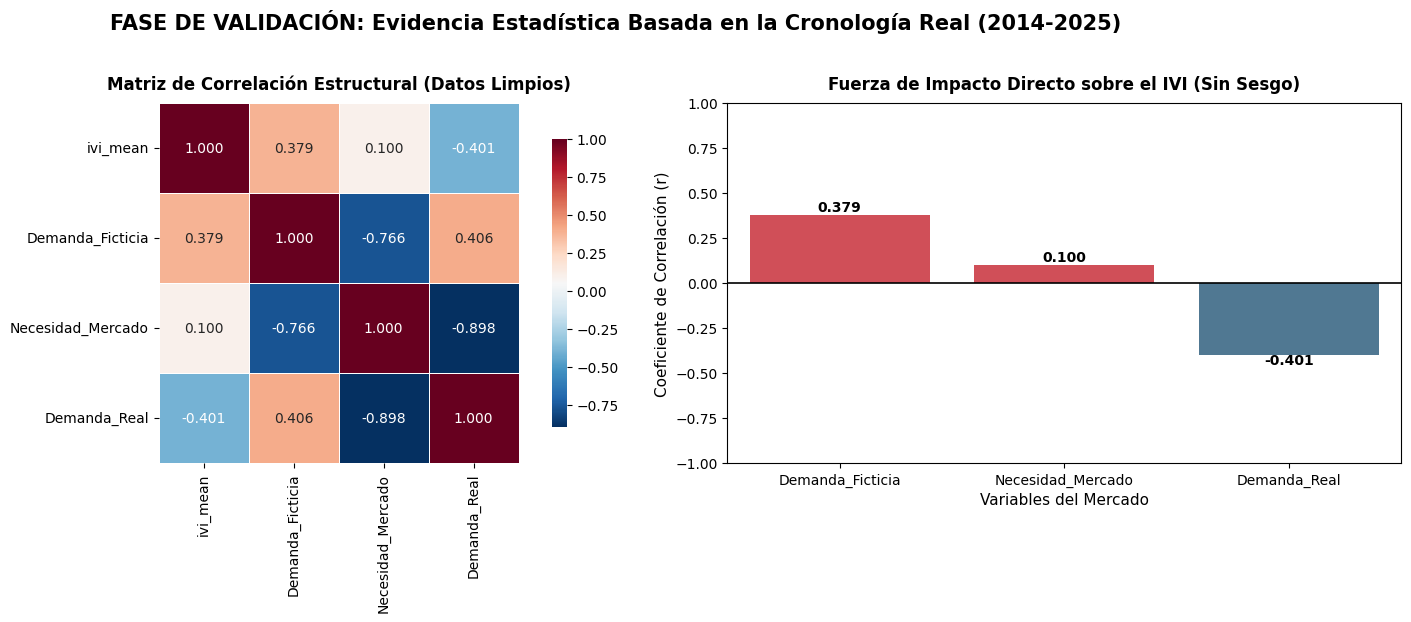

In [6]:
# --- 1.5 VISUALIZATION OF CORRELATION MATRIX & IMPACT (CLEAN DATA) ---
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el lienzo para dos gráficas paralelas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Mapa de Calor (Heatmap) de la Matriz Completa con datos filtrados
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".3f", linewidths=.5,
            square=True, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title('Matriz de Correlación Estructural (Datos Limpios)', fontsize=12, fontweight='bold', pad=10)

# Gráfica 2: Gráfico de Barras de Impacto Específico sobre el IVI
ivi_impact = corr_matrix['ivi_mean'].drop('ivi_mean').sort_values(ascending=False)

# Asignar colores dinámicos: Rojo para impacto positivo, Azul para relación inversa
bar_colors = ['#E63946' if x > 0 else '#457B9D' for x in ivi_impact]

# Versión optimizada (hue asignado y legend=False) para evitar el FutureWarning de Seaborn
sns.barplot(x=ivi_impact.index, y=ivi_impact.values, hue=ivi_impact.index,
            palette=bar_colors, legend=False, ax=axes[1])

axes[1].axhline(0, color='black', linewidth=1.2, linestyle='-')
axes[1].set_title('Fuerza de Impacto Directo sobre el IVI (Sin Sesgo)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Coeficiente de Correlación (r)', fontsize=11)
axes[1].set_xlabel('Variables del Mercado', fontsize=11)
axes[1].set_ylim(-1, 1)  # Rango estándar de correlación

# Añadir etiquetas de valor sobre las barras para una lectura rápida
for i, v in enumerate(ivi_impact.values):
    axes[1].text(i, v + (0.02 if v > 0 else -0.05), f"{v:.3f}",
                 ha='center', fontweight='bold', fontsize=10)

# Título Principal del Bloque de Validación
plt.suptitle('FASE DE VALIDACIÓN: Evidencia Estadística Basada en la Cronología Real (2014-2025)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- PROYECCIONES CORREGIDAS DEL IVI PROMEDIO (2026 - 2030) ---
 Año  IVI_Promedio_Predicho
2026              13.398675
2027              14.712263
2028              16.164025
2029              17.753962
2030              19.482074


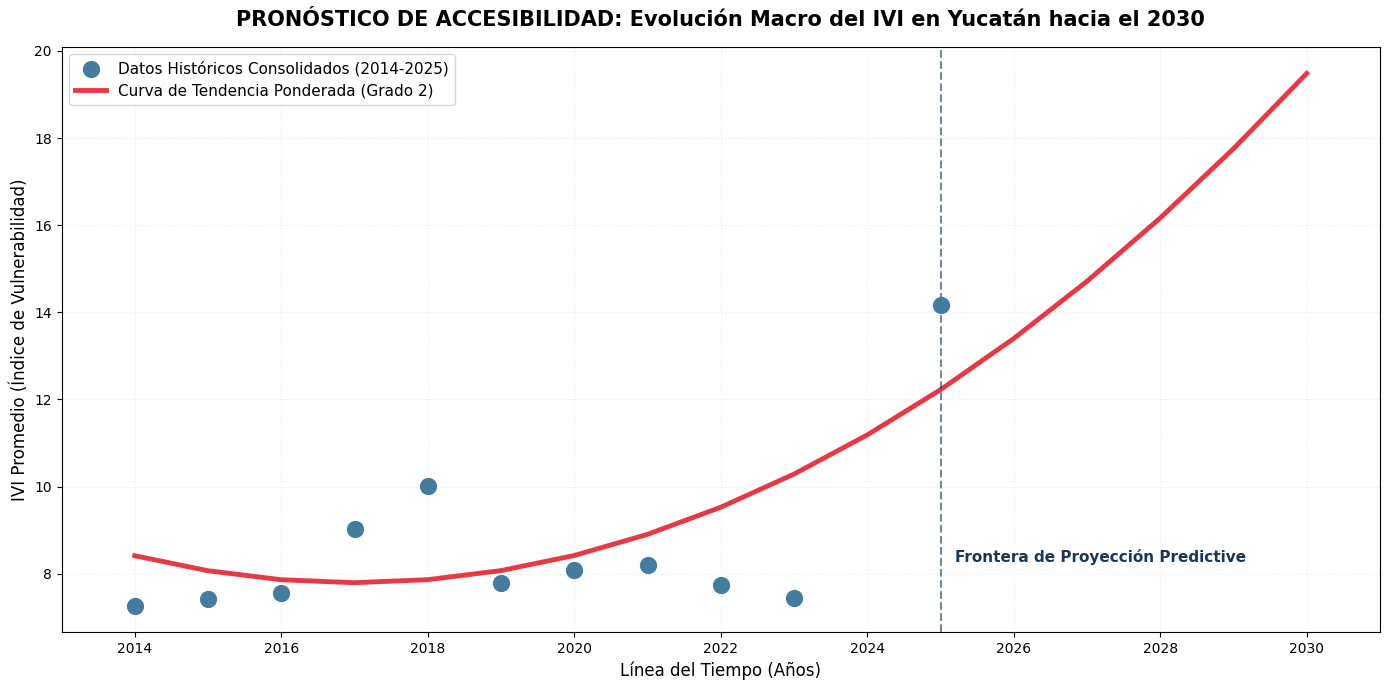

In [7]:
# --- 2. MACHINE LEARNING & ENHANCED VISUALIZATION ---
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 2.1 Preparar variables
X_hist = yearly_data['Year'].values.reshape(-1, 1)
y_hist = yearly_data['ivi_mean'].values
weights = yearly_data['Statistical_Weight'].values

# 2.2 Transformación Polinómica Grado 2
poly = PolynomialFeatures(degree=2)
X_poly_hist = poly.fit_transform(X_hist)

# 2.3 Entrenar el modelo con pesos estadísticos
model = LinearRegression()
model.fit(X_poly_hist, y_hist, sample_weight=weights)

# 2.4 Proyectar hasta el 2030
future_years = np.array(range(2014, 2031)).reshape(-1, 1)
X_poly_future = poly.transform(future_years)
y_pred_future = model.predict(X_poly_future)

# 2.5 Crear Dataframe de Proyecciones
projections_df = pd.DataFrame({
    'Año': future_years.flatten(),
    'IVI_Promedio_Predicho': y_pred_future
})

print("--- PROYECCIONES CORREGIDAS DEL IVI PROMEDIO (2026 - 2030) ---")
print(projections_df[projections_df['Año'] >= 2026].to_string(index=False))

# --- 2.6 VISUALIZACIÓN OPTIMIZADA DEL ENTORNO ---
plt.figure(figsize=(14, 7))

# Datos Reales históricos
plt.scatter(X_hist, y_hist, color='#457B9D', s=130, label='Datos Históricos Consolidados (2014-2025)', zorder=3)

# Línea de proyección continua y elegante
plt.plot(future_years, y_pred_future, color='#E63946', linewidth=3.5, label='Curva de Tendencia Ponderada (Grado 2)')

# Línea divisoria del Presente / Futuro
plt.axvline(x=2025, color='#1D3557', linestyle='--', alpha=0.6, linewidth=1.5)
plt.text(2025.2, min(y_hist) + 1, 'Frontera de Proyección Predictive', color='#1D3557', fontsize=11, fontweight='bold')

# Ajustes de visualización para expandir el foco
plt.xlim(2013, 2031)  # Hace que el gráfico empiece justo en 2013 y termine en 2031 sin vacíos
plt.xticks(range(2014, 2031, 2), fontsize=10)
plt.title('PRONÓSTICO DE ACCESIBILIDAD: Evolución Macro del IVI en Yucatán hacia el 2030', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Línea del Tiempo (Años)', fontsize=12)
plt.ylabel('IVI Promedio (Índice de Vulnerabilidad)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()